# A2 Scoring + EDA (Target 8)
Monthly climatology (average across all years) per location, plus week-of-year score climatology.

In [65]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
DATA_DIR = Path("Data/processed")


In [66]:
yellowknife = pd.read_csv(DATA_DIR / "yellowknife_moon_night.csv", parse_dates=["timestamp_utc"])

yellowknife.head()


,timestamp_utc,location,is_night,cloud_cover,wind_speed_10m (km/h),kp,moon_altitude_deg,moon_illumination,D,F_cloud,F_moon,F_kp,visibility_score
0,1998-01-01 00:00:00+00:00,yellowknife,False,12,14.5,0.667,NaN,0.000000,0.0,1.0,1.0,0.0,0.0
1,1998-01-01 01:00:00+00:00,yellowknife,False,23,14.4,0.667,NaN,0.000000,0.0,1.0,1.0,0.0,0.0
2,1998-01-01 02:00:00+00:00,yellowknife,True,99,14.2,0.667,-1.480050,0.070419,1.0,0.0,1.0,0.0,0.0
3,1998-01-01 03:00:00+00:00,yellowknife,True,96,14.5,1.333,-8.503104,0.072852,1.0,0.0,1.0,0.0,0.0
4,1998-01-01 04:00:00+00:00,yellowknife,True,89,15.0,1.333,-14.912796,0.075325,1.0,0.0,1.0,0.0,0.0


In [67]:
from pathlib import Path

BASE_DIR = Path('.').resolve()
DL_CSV = BASE_DIR / 'keograms_yellowknife' / 'yellowknife_keogram_downloads.csv'
downloads = pd.read_csv(DL_CSV, parse_dates=['timestamp_utc'])
downloads_ok = downloads[downloads['ok'] == True].copy()
start_date = downloads_ok['timestamp_utc'].min()
end_date = downloads_ok['timestamp_utc'].max()
start_date, end_date


(Timestamp('2023-04-01 06:00:00+0000', tz='UTC'),
 Timestamp('2025-12-31 14:00:00+0000', tz='UTC'))

In [68]:
# Filter Yellowknife to the keogram-available window
yellowknife = yellowknife[(yellowknife['timestamp_utc'] >= start_date) & (yellowknife['timestamp_utc'] <= end_date)].copy()
yellowknife.head()


,timestamp_utc,location,is_night,cloud_cover,wind_speed_10m (km/h),kp,moon_altitude_deg,moon_illumination,D,F_cloud,F_moon,F_kp,visibility_score
221310,2023-04-01 06:00:00+00:00,yellowknife,True,100,24.3,1.667,44.505991,0.781804,1.0,0.0,0.290929,0.0000,0.0
221311,2023-04-01 07:00:00+00:00,yellowknife,True,100,24.6,1.667,39.714114,0.785057,1.0,0.0,0.286591,0.0000,0.0
221312,2023-04-01 08:00:00+00:00,yellowknife,True,100,24.9,1.667,33.729455,0.788293,1.0,0.0,0.282276,0.0000,0.0
221313,2023-04-01 09:00:00+00:00,yellowknife,True,100,25.2,3.333,27.081852,0.791513,1.0,0.0,0.277983,0.3332,0.0
221314,2023-04-01 10:00:00+00:00,yellowknife,True,100,25.2,3.333,20.201587,0.794716,1.0,0.0,0.273712,0.3332,0.0


## 0) Time aggregation convention
Group by (location, night_date_local) as the EDA atomic unit, then aggregate by month (climatology).

In [69]:
def add_night_date(df, tz):
    df = df.copy()
    df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], utc=True)
    df["timestamp_local"] = df["timestamp_utc"].dt.tz_convert(tz)
    df["night_date_local"] = df["timestamp_local"].dt.date
    return df

def nightly_aggregate(df, location_name):
    night = df[df["is_night"]].copy()
    g = night.groupby("night_date_local")
    out = pd.DataFrame({
        "night_duration_hours": g["is_night"].size(),
        "cloud_night_mean": g["cloud_cover"].mean(),
        "cloud_night_p90": g["cloud_cover"].quantile(0.90),
        "kp_night_max": g["kp"].max(),
        "kp_night_mean": g["kp"].mean(),
        "moon_alt_night_max": g["moon_altitude_deg"].max(),
        "moon_alt_night_mean": g["moon_altitude_deg"].mean(),
        "S_night_mean": g["visibility_score"].mean(),
        "S_night_max": g["visibility_score"].max(),
    })
    out["location"] = location_name
    return out.reset_index()

yellowknife = add_night_date(yellowknife, "America/Yellowknife")

yellowknife_night = nightly_aggregate(yellowknife, "yellowknife")

nightly_all = yellowknife_night.copy()
nightly_all["night_date_local"] = pd.to_datetime(nightly_all["night_date_local"])
nightly_all["month"] = nightly_all["night_date_local"].dt.month
nightly_all.head()


,night_date_local,night_duration_hours,cloud_night_mean,cloud_night_p90,kp_night_max,kp_night_mean,moon_alt_night_max,moon_alt_night_mean,S_night_mean,S_night_max,location,month
0,2023-04-01,5,100.00,100.0,3.333,2.33340,44.505991,33.046600,0.0,0.0,yellowknife,4
1,2023-04-02,4,100.00,100.0,3.333,2.83350,42.616815,36.013165,0.0,0.0,yellowknife,4
2,2023-04-03,4,92.75,100.0,1.667,1.41650,38.693968,34.057733,0.0,0.0,yellowknife,4
3,2023-04-04,4,40.50,58.0,2.333,2.33300,33.119727,30.557250,0.0,0.0,yellowknife,4
4,2023-04-05,4,0.00,0.0,2.000,1.75025,27.212508,25.758058,0.0,0.0,yellowknife,4


## Monthly climatology (average across all years)

In [70]:
monthly = nightly_all.groupby(["location", "month"]).agg(
    night_duration_mean=("night_duration_hours", "mean"),
    night_duration_std=("night_duration_hours", "std"),
    cloud_mean=("cloud_night_mean", "mean"),
    cloud_std=("cloud_night_mean", "std"),
    cloud_p90_mean=("cloud_night_p90", "mean"),
    kp_max_mean=("kp_night_max", "mean"),
    kp_mean_mean=("kp_night_mean", "mean"),
    moon_alt_max_mean=("moon_alt_night_max", "mean"),
    S_mean=("S_night_mean", "mean"),
    S_std=("S_night_mean", "std"),
    S_max_mean=("S_night_max", "mean")
).reset_index()
monthly.head()

weekly = nightly_all.copy()
weekly["week"] = weekly["night_date_local"].dt.isocalendar().week.astype(int)
weekly_agg = weekly.groupby(["location", "week"]).agg(
    night_duration_mean=("night_duration_hours", "mean"),
    night_duration_std=("night_duration_hours", "std"),
    cloud_mean=("cloud_night_mean", "mean"),
    cloud_std=("cloud_night_mean", "std"),
    cloud_p90_mean=("cloud_night_p90", "mean"),
    kp_max_mean=("kp_night_max", "mean"),
    kp_mean_mean=("kp_night_mean", "mean"),
    moon_alt_max_mean=("moon_alt_night_max", "mean"),
    S_mean=("S_night_mean", "mean"),
    S_std=("S_night_mean", "std"),
    S_max_mean=("S_night_max", "mean")
).reset_index()

# Fill missing weeks per location with 0 night duration to avoid gaps
all_weeks = range(1, 54)
locations = weekly_agg["location"].unique()
full_index = pd.MultiIndex.from_product([locations, all_weeks], names=["location", "week"])
weekly_full = weekly_agg.set_index(["location", "week"]).reindex(full_index).reset_index()
weekly_full["night_duration_mean"] = weekly_full["night_duration_mean"].fillna(0)
weekly_full["night_duration_std"] = weekly_full["night_duration_std"].fillna(0)
weekly_full["cloud_mean"] = weekly_full["cloud_mean"].fillna(0)
weekly_full["cloud_std"] = weekly_full["cloud_std"].fillna(0)
weekly_full["kp_max_mean"] = weekly_full["kp_max_mean"].fillna(0)
weekly_full["kp_mean_mean"] = weekly_full["kp_mean_mean"].fillna(0)
weekly_full["moon_alt_max_mean"] = weekly_full["moon_alt_max_mean"].fillna(0)
weekly_full["S_mean"] = weekly_full["S_mean"].fillna(0)
weekly_full["S_std"] = weekly_full["S_std"].fillna(0)
weekly_full["S_max_mean"] = weekly_full["S_max_mean"].fillna(0)


## 1) Nighttime duration (monthly climatology)

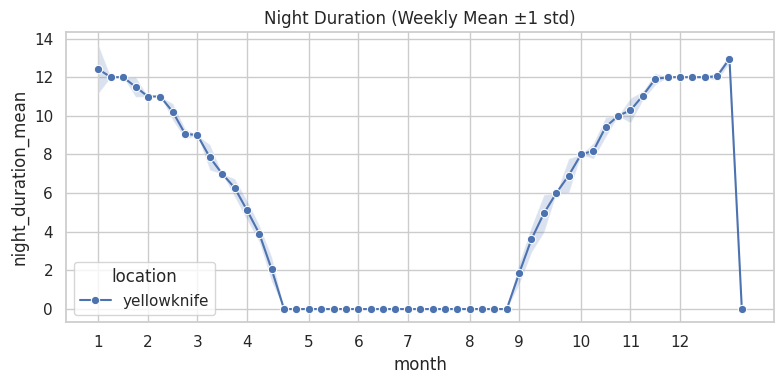

In [71]:
plt.figure(figsize=(8, 4))
sns.lineplot(data=weekly_full, x="week", y="night_duration_mean", hue="location", marker="o")
for loc in weekly_full["location"].unique():
    sub = weekly_full[weekly_full["location"] == loc]
    plt.fill_between(sub["week"], sub["night_duration_mean"] - sub["night_duration_std"], sub["night_duration_mean"] + sub["night_duration_std"], alpha=0.2)
plt.title("Night Duration (Weekly Mean ±1 std)")
# Approx month ticks at week numbers for a 1–12 month look
month_tick_weeks = [1, 5, 9, 13, 18, 22, 26, 31, 35, 40, 44, 48]
plt.xticks(month_tick_weeks, range(1, 13))
plt.xlabel("month")
plt.tight_layout()
plt.show()


## 2) Cloud coverage (night, monthly climatology)

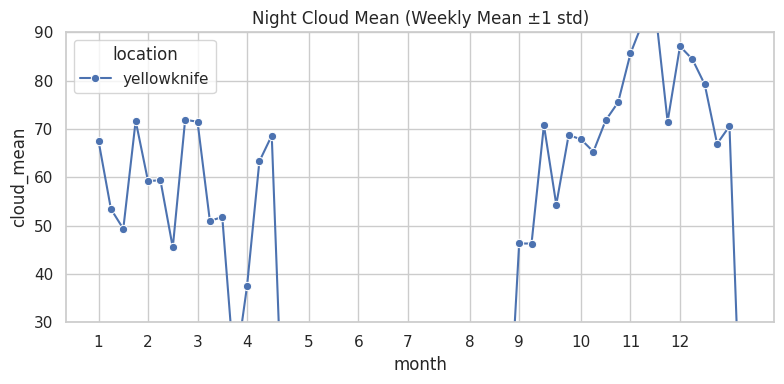

In [72]:
plt.figure(figsize=(8, 4))
sns.lineplot(data=weekly_full, x="week", y="cloud_mean", hue="location", marker="o")
for loc in weekly_full["location"].unique():
    sub = weekly_full[weekly_full["location"] == loc]
    # plt.fill_between(sub["week"], sub["cloud_mean"] - sub["cloud_std"], sub["cloud_mean"] + sub["cloud_std"], alpha=0.2)
plt.title("Night Cloud Mean (Weekly Mean ±1 std)")
# Approx month ticks at week numbers for a 1–12 month look
month_tick_weeks = [1, 5, 9, 13, 18, 22, 26, 31, 35, 40, 44, 48]
plt.xticks(month_tick_weeks, range(1, 13))
plt.xlabel("month")
plt.ylim((30,90))
plt.tight_layout()
plt.show()


## 3) Kp activity (night, monthly climatology)

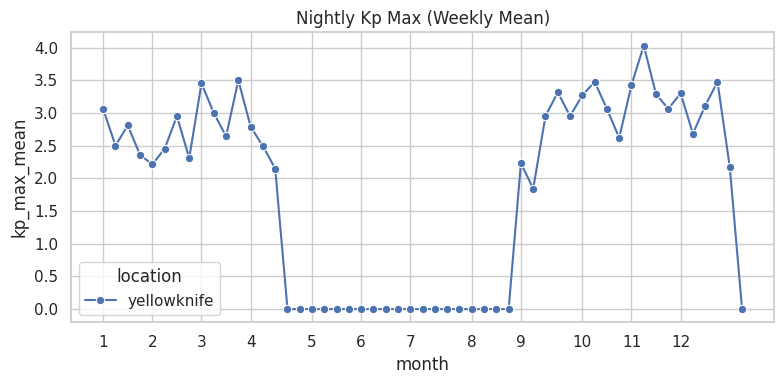

In [73]:
plt.figure(figsize=(8, 4))
sns.lineplot(data=weekly_full, x="week", y="kp_max_mean", hue="location", marker="o")
plt.title("Nightly Kp Max (Weekly Mean)")
# Approx month ticks at week numbers for a 1–12 month look
month_tick_weeks = [1, 5, 9, 13, 18, 22, 26, 31, 35, 40, 44, 48]
plt.xticks(month_tick_weeks, range(1, 13))
plt.xlabel("month")
plt.tight_layout()
plt.show()


## 4) Moon altitude (night, monthly climatology)

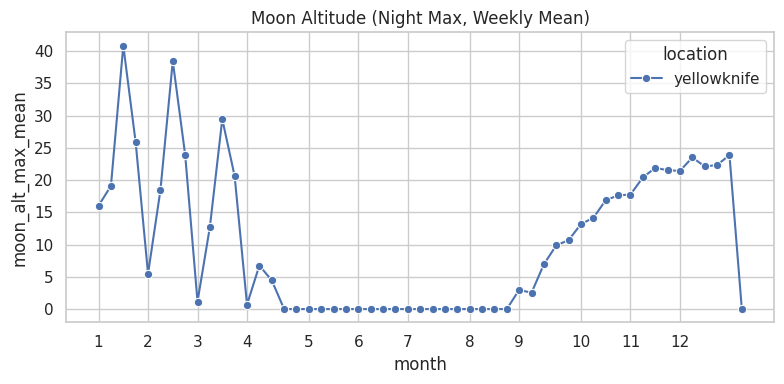

In [74]:
plt.figure(figsize=(8, 4))
sns.lineplot(data=weekly_full, x="week", y="moon_alt_max_mean", hue="location", marker="o")
plt.title("Moon Altitude (Night Max, Weekly Mean)")
# Approx month ticks at week numbers for a 1–12 month look
month_tick_weeks = [1, 5, 9, 13, 18, 22, 26, 31, 35, 40, 44, 48]
plt.xticks(month_tick_weeks, range(1, 13))
plt.xlabel("month")
plt.tight_layout()
plt.show()


## 5) Visibility score (monthly climatology)

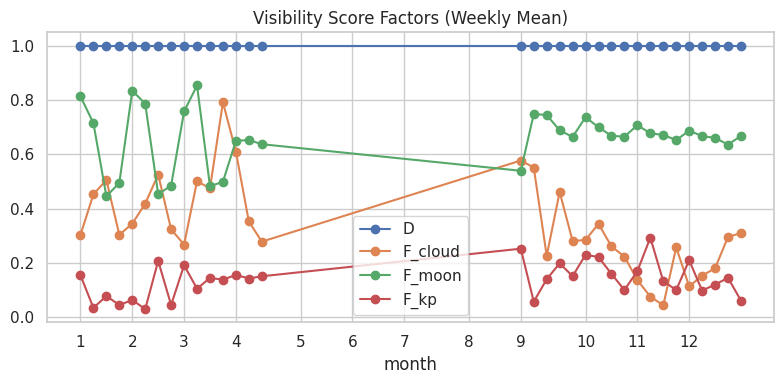

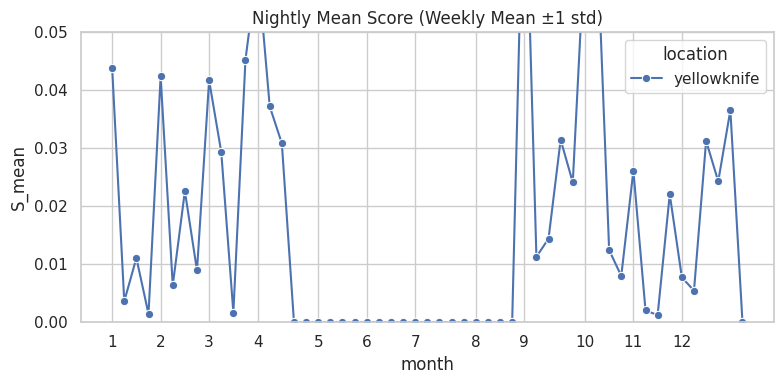

In [78]:
# Weekly mean of visibility-score factors (D, F_cloud, F_moon, F_kp)
factor_cols = ['D', 'F_cloud', 'F_moon', 'F_kp']
missing = [c for c in factor_cols if c not in yellowknife.columns]
if missing:
    raise KeyError(f'Missing columns in yellowknife: {missing}')

yellowknife['week'] = yellowknife['timestamp_utc'].dt.isocalendar().week.astype(int)
weekly_factors = (
    yellowknife[yellowknife['is_night'] == True]
    .groupby('week')[factor_cols]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 4))
for col in factor_cols:
    plt.plot(weekly_factors['week'], weekly_factors[col], marker='o', label=col)
plt.title('Visibility Score Factors (Weekly Mean)')
month_tick_weeks = [1, 5, 9, 13, 18, 22, 26, 31, 35, 40, 44, 48]
plt.xticks(month_tick_weeks, range(1, 13))
plt.xlabel('month')
plt.tight_layout()
plt.legend()
plt.show()
plt.figure(figsize=(8, 4))
sns.lineplot(data=weekly_full, x="week", y="S_mean", hue="location", marker="o")
for loc in weekly_full["location"].unique():
    sub = weekly_full[weekly_full["location"] == loc]
    # plt.fill_between(sub["week"], sub["S_mean"] - sub["S_std"], sub["S_mean"] + sub["S_std"], alpha=0.2)
plt.title("Nightly Mean Score (Weekly Mean ±1 std)")
# Approx month ticks at week numbers for a 1–12 month look
month_tick_weeks = [1, 5, 9, 13, 18, 22, 26, 31, 35, 40, 44, 48]
plt.xticks(month_tick_weeks, range(1, 13))
plt.xlabel("month")
plt.ylim((0,0.05))
plt.tight_layout()
plt.show()


COntrary to the more year analysis month 1,2 show very low nightly mean score.

Which is quite puzzling because i dont see it in the cloud or kp.

From the score component analysis we see however a strong effect of negative coupling of moon cloud and kp.

## Keogram Scoring (Yellowknife)
Score downloaded keograms and merge with hourly data.


In [ ]:

BASE_DIR = Path('.').resolve()
LOCATION = 'fortsmith'
DATA_DIR = BASE_DIR / 'Data' / 'processed'
OUT_DIR = BASE_DIR / f'keograms_{LOCATION}'
JOBS_PATH = BASE_DIR / f'{LOCATION}_keogram_jobs.csv'

DATA_DIR, OUT_DIR

# ## 1) Load Kiruna hourly table
# Using the existing `kiruna_moon_night.csv` produced in A1.
#
yellowknife_pd = pd.read_csv(DATA_DIR / f'{LOCATION}_moon_night.csv', parse_dates=['timestamp_utc'])
yellowknife_pd.head()

# ## 2) Build download jobs (night hours only)
# Restrict to last ~10 years (min 2015-01-01).
#
yellowknife_pd = yellowknife_pd.copy()
yellowknife_pd['timestamp_utc'] = pd.to_datetime(yellowknife_pd['timestamp_utc'], utc=True)

latest = yellowknife_pd['timestamp_utc'].max()
start_10y = latest - pd.DateOffset(years=10)
start_date = max(pd.Timestamp('2015-01-01', tz='UTC'), start_10y)

jobs = yellowknife_pd[(yellowknife_pd['is_night']) & (yellowknife_pd['timestamp_utc'] >= start_date)]
jobs = jobs[['timestamp_utc']].drop_duplicates().sort_values('timestamp_utc')
JOBS_PATH = BASE_DIR / f'{LOCATION}_keogram_jobs.csv'
jobs.to_csv(JOBS_PATH, index=False)

start_date, latest, len(jobs)



Use `download_keograms.py` to download all images from the `'{LOCATION}_keogram_jobs.csv'` created. Then run next cells

In [83]:
from pathlib import Path
from keogram_utils import KeogramScorer

OUT_DIR = Path('.') / 'keograms_yellowknife'
downloads = pd.read_csv(OUT_DIR / 'yellowknife_keogram_downloads.csv', parse_dates=['timestamp_utc'])
downloads_ok = downloads[downloads['ok'] == True].copy()
#
# scorer = KeogramScorer()
# rows = []
# paths = downloads_ok["local_path"].dropna().tolist()
# n = len(paths)
# step = max(1, n // 100)  # 2.5% increments
#
# for i, p in enumerate(paths, 1):
#   scores = scorer.score_image(p, crop=True)
#   scores["local_path"] = p
#   rows.append(scores)
#
#   if i % step == 0 or i == n:
#       pct = (i / n) * 100
#       print(f"{pct:5.1f}%  ({i}/{n})")
#
#
# scores_df = pd.DataFrame(rows)
# scores_path = OUT_DIR / 'yellowknife_keogram_scores.csv'
# scores_df.to_csv(scores_path, index=False)
# scores_df.head()


  9.9%  (428/4303)
 12.4%  (535/4303)
 14.9%  (642/4303)
 17.4%  (749/4303)
 19.9%  (856/4303)
 22.4%  (963/4303)
 24.9%  (1070/4303)
 27.4%  (1177/4303)
 29.8%  (1284/4303)
 32.3%  (1391/4303)
 34.8%  (1498/4303)
 37.3%  (1605/4303)
 39.8%  (1712/4303)
 42.3%  (1819/4303)
 44.8%  (1926/4303)
 47.2%  (2033/4303)
 49.7%  (2140/4303)
 52.2%  (2247/4303)
 54.7%  (2354/4303)
 57.2%  (2461/4303)
 59.7%  (2568/4303)
 62.2%  (2675/4303)
 64.7%  (2782/4303)
 67.1%  (2889/4303)
 69.6%  (2996/4303)
 72.1%  (3103/4303)
 74.6%  (3210/4303)
 77.1%  (3317/4303)
 79.6%  (3424/4303)
 82.1%  (3531/4303)
 84.5%  (3638/4303)
 87.0%  (3745/4303)
 89.5%  (3852/4303)
 92.0%  (3959/4303)
 94.5%  (4066/4303)
 97.0%  (4173/4303)
 99.5%  (4280/4303)
100.0%  (4303/4303)


,green_score,green_coverage,green_intensity,red_score,red_coverage,red_intensity,white_score,white_coverage,white_brightness,black_score,black_coverage,black_darkness,aurora_score,local_path
0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.049582,0.049755,0.996523,0.0,0.0,0.0,0.000000,/media/nuopel/DATA/ProjectsAndTools/1_Projects...
1,0.001277,0.007330,0.174267,0.0,0.0,0.0,0.040977,0.048423,0.846230,0.0,0.0,0.0,0.001215,/media/nuopel/DATA/ProjectsAndTools/1_Projects...
2,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.001695,0.002219,0.763836,0.0,0.0,0.0,0.000000,/media/nuopel/DATA/ProjectsAndTools/1_Projects...
3,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,/media/nuopel/DATA/ProjectsAndTools/1_Projects...
4,0.002067,0.016308,0.126755,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.002067,/media/nuopel/DATA/ProjectsAndTools/1_Projects...


In [120]:
scores_path = OUT_DIR / 'yellowknife_keogram_scores.csv'
downloads1 = pd.read_csv(scores_path)

downloads1.head

<bound method NDFrame.head of       green_score  green_coverage  green_intensity  red_score  red_coverage  \
0        0.000000        0.000000         0.000000   0.000000      0.000000   
1        0.001277        0.007330         0.174267   0.000000      0.000000   
2        0.000000        0.000000         0.000000   0.000000      0.000000   
3        0.000000        0.000000         0.000000   0.000000      0.000000   
4        0.002067        0.016308         0.126755   0.000000      0.000000   
...           ...             ...              ...        ...           ...   
4298     0.000039        0.000273         0.144280   0.000000      0.000000   
4299     0.001148        0.008935         0.128450   0.000004      0.000117   
4300     0.001861        0.020289         0.091735   0.000024      0.000623   
4301     0.042641        0.458842         0.092932   0.000018      0.000445   
4302     0.032293        0.366305         0.088160   0.000047      0.001306   

      red_intensity  

## Merge scores with hourly table
Add image-derived features back to the hourly table by timestamp.


In [113]:
downloads = pd.read_csv(OUT_DIR / 'yellowknife_keogram_downloads.csv', parse_dates=['timestamp_utc'])
downloads_ok = downloads[downloads['ok'] == True].copy()
downloads = downloads.merge(scores_df, on='local_path', how='left')
merged = yellowknife.merge(
    downloads[['timestamp_utc','local_path','ok','error','green_score','red_score','white_score','aurora_score']],
    on='timestamp_utc', how='left'
)

AURORA_THR = 0.001  # tune threshold
merged['event_flag'] = (merged['aurora_score'].fillna(0) >= AURORA_THR).astype(int)

out_path = OUT_DIR / 'yellowknife_hourly_with_images.csv'
merged.to_csv(out_path, index=False)
out_path, merged.head()


(PosixPath('keograms_yellowknife/yellowknife_hourly_with_images.csv'),
               timestamp_utc     location  is_night  cloud_cover  \
 0 2023-04-01 06:00:00+00:00  yellowknife      True          100   
 1 2023-04-01 07:00:00+00:00  yellowknife      True          100   
 2 2023-04-01 08:00:00+00:00  yellowknife      True          100   
 3 2023-04-01 09:00:00+00:00  yellowknife      True          100   
 4 2023-04-01 10:00:00+00:00  yellowknife      True          100   
 
    wind_speed_10m (km/h)     kp  moon_altitude_deg  moon_illumination    D  \
 0                   24.3  1.667          44.505991           0.781804  1.0   
 1                   24.6  1.667          39.714114           0.785057  1.0   
 2                   24.9  1.667          33.729455           0.788293  1.0   
 3                   25.2  3.333          27.081852           0.791513  1.0   
 4                   25.2  3.333          20.201587           0.794716  1.0   
 
    F_cloud  ...  night_date_local  week  \

## Quick checks / coupling
Compare image features to moon/cloud/Kp.


In [85]:
subset = merged[merged['is_night'] == True].copy()
cols = ['green_score','white_score','aurora_score','moon_altitude_deg','moon_illumination','cloud_cover','kp']
subset[cols].corr().loc[['green_score','white_score','aurora_score'], ['moon_altitude_deg','moon_illumination','cloud_cover','kp']]


,moon_altitude_deg,moon_illumination,cloud_cover,kp
green_score,-0.065552,-0.044800,-0.080711,0.180688
white_score,0.386610,0.348407,0.085664,-0.031734
aurora_score,-0.067848,-0.046795,-0.080895,0.180316


## Aurora score distribution (hist + ECDF)


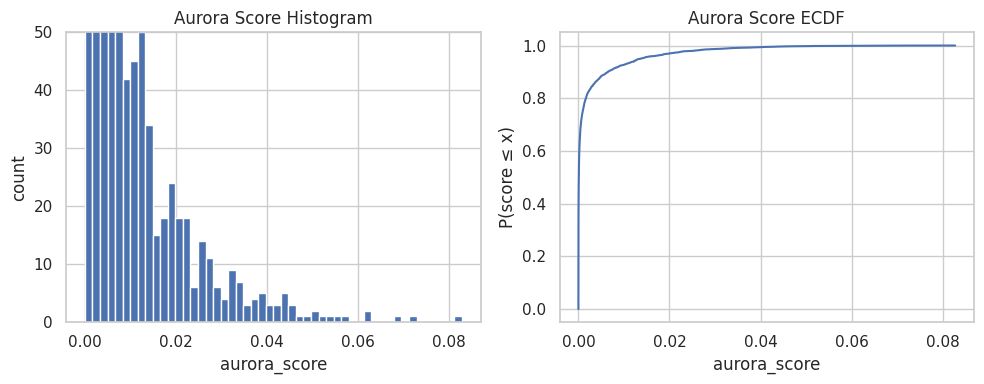

In [157]:
# Histogram + ECDF of aurora_score
vals = merged[merged['ok'] == True]['aurora_score'].dropna().values
vals = np.sort(vals)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].hist(vals, bins=50)
ax[0].set_title('Aurora Score Histogram')
ax[0].set_xlabel('aurora_score')
ax[0].set_ylim((0,50))
ax[0].set_ylabel('count')

ecdf_y = np.arange(1, len(vals) + 1) / len(vals)
ax[1].plot(vals, ecdf_y)
ax[1].set_title('Aurora Score ECDF')
ax[1].set_xlabel('aurora_score')
ax[1].set_ylabel('P(score ≤ x)')

plt.tight_layout()
plt.show()


- Aurora score is highly right‑skewed: most hours are near zero, with a long
    tail of higher values.
- Events are rare: the ECDF rises steeply near 0, meaning a large fraction of
hours have very low scores.
- This supports using a high‑percentile threshold (e.g., 90–95%) to define
“aurora present.”


In [160]:
 np.quantile(vals, 0.95)

np.float64(0.013633209943420974)

## Keogram EDA: green vs Kp, white vs moon/cloud


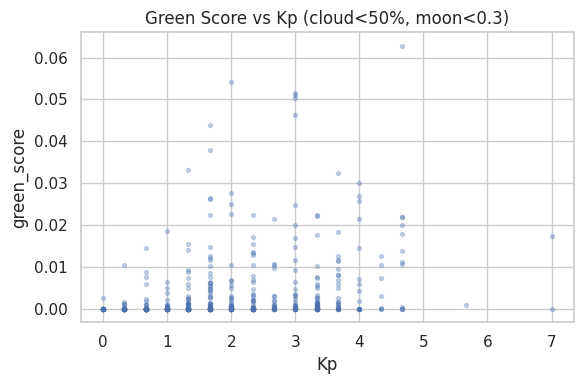

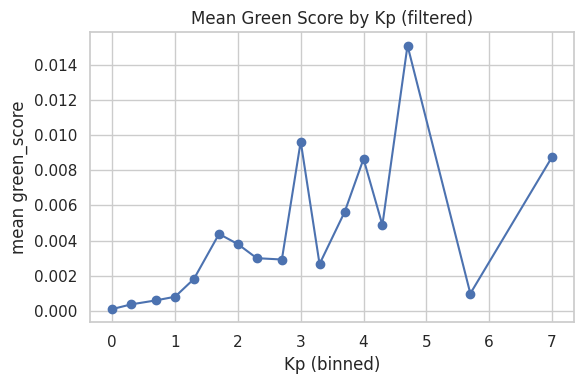

In [124]:
eda = merged[(merged["is_night"] == True) & (merged["ok"] == True)].copy()

# tweak thresholds as you like
filtered = eda[(eda["cloud_cover"] < 40) & (eda["moon_illumination"] < 0.5)]

# Scatter
plt.figure(figsize=(6, 4))
plt.scatter(filtered["kp"], filtered["green_score"], s=8, alpha=0.3)
plt.title("Green Score vs Kp (cloud<50%, moon<0.3)")
plt.xlabel("Kp")
plt.ylabel("green_score")
plt.tight_layout()
plt.show()

# Binned mean
kp_bin = filtered["kp"].round(1)
binned = filtered.groupby(kp_bin)["green_score"].mean()
plt.figure(figsize=(6, 4))
plt.plot(binned.index, binned.values, marker="o")
plt.title("Mean Green Score by Kp (filtered)")
plt.xlabel("Kp (binned)")
plt.ylabel("mean green_score")
plt.tight_layout()
plt.show()

: under clear + dark conditions, the mean green score
  increases with Kp up to ~4–5, then becomes noisy. That’s expected because
  higher Kp bins have fewer samples.

  - Filtering for cloud < 50% and moon < 0.3 reveals a clear positive trend
    between Kp and green signal at low–moderate Kp.
  - The spikes above Kp≈5 are likely small‑sample noise (verify with counts per
    bin).
  - This supports the hypothesis that Kp drives green aurora visibility, but
    only when sky conditions are favorable.



/tmp/ipykernel_37554/4070041807.py:14: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  grid = eda.pivot_table(


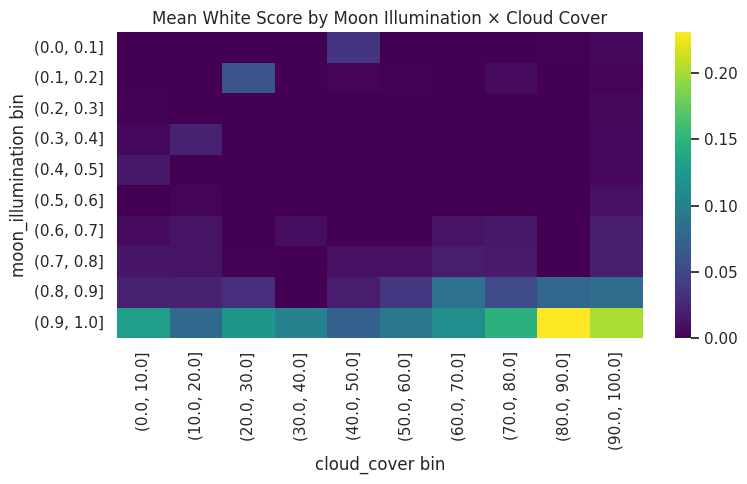

In [153]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

eda = merged[(merged["is_night"] == True) & (merged["ok"] == True)].copy()

moon_bins = np.linspace(0, 1, 11)
cloud_bins = np.linspace(0, 100, 11)

eda["moon_bin"] = pd.cut(eda["moon_illumination"], bins=moon_bins)
eda["cloud_bin"] = pd.cut(eda["cloud_cover"], bins=cloud_bins)

grid = eda.pivot_table(
  index="moon_bin",
  columns="cloud_bin",
  values="white_score",
  aggfunc="mean"
)

plt.figure(figsize=(8, 5))
sns.heatmap((abs(grid)), cmap="viridis")
plt.title("Mean White Score by Moon Illumination × Cloud Cover")
plt.xlabel("cloud_cover bin")
plt.ylabel("moon_illumination bin")
plt.tight_layout()
plt.show()



well when moon and cloud, white filter is max but otherwise not really. likelly moon trigger reflexion and increase score in white filter but cloud and moon alone are not enough to activate the filter in a meaninfull way.


## Manual labeling: sample images by aurora_score bins
Select a few images per score bin and display them with metadata.


In [190]:
MANUAL_BINS

array([3.78175587e-11, 1.36263167e-09, 4.90979625e-08, 1.76908402e-06,
       6.37431395e-05, 2.29677493e-03, 8.27567506e-02])

In [298]:
import numpy as np
from PIL import Image

# Choose bin edges: quantiles (default) or manual edges
USE_QUANTILES = False
MANUAL_BINS = [0.0, 0.001, 0.005, 0.013, 0.025, 0.05]  # used only if USE_QUANTILES = False
SAMPLES_PER_BIN = 8

scores = scores_df.copy()
if USE_QUANTILES:
    bins = np.quantile(scores['aurora_score'], np.linspace(0, 1, 8))
    bins = np.unique(bins)
else:
    bins = np.array(MANUAL_BINS)

scores['bin'] = pd.cut(scores['aurora_score'], bins=bins, include_lowest=True)

# Attach metadata from merged
meta_cols = ['local_path','kp','cloud_cover','moon_illumination']
meta = merged[meta_cols].drop_duplicates('local_path')
scores = scores.merge(meta, on='local_path', how='left')


# Display images with titles (score + kp/cloud/moon)
CLOUD_MAX = 100
CLOUD_MIN = 0
MOON_MAX = 0.95

scores_filt = scores[
  (scores["cloud_cover"] <= CLOUD_MAX) &
  (scores["cloud_cover"] >= CLOUD_MIN) &
  (scores["moon_illumination"] < MOON_MAX)
].copy()

samples = (
  scores_filt.groupby("bin", group_keys=False)
  .apply(lambda g: g.sample(min(SAMPLES_PER_BIN, len(g)), random_state=0))
)
samples.head()

/tmp/ipykernel_37554/1426219787.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  scores_filt.groupby("bin", group_keys=False)
/tmp/ipykernel_37554/1426219787.py:37: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(SAMPLES_PER_BIN, len(g)), random_state=0))


,green_score,green_coverage,green_intensity,red_score,red_coverage,red_intensity,white_score,white_coverage,white_brightness,black_score,black_coverage,black_darkness,aurora_score,local_path,bin,kp,cloud_cover,moon_illumination
533,0.000002,0.000052,0.038146,5.586519e-06,0.000231,0.024217,0.051689,0.059625,0.866898,0.027502,0.029045,0.946858,5.253425e-06,/media/nuopel/DATA/ProjectsAndTools/1_Projects...,"(-0.001, 0.001]",1.000,100,0.673408
1297,0.000024,0.000445,0.054147,8.421748e-06,0.000119,0.070824,0.000000,0.000000,0.000000,0.900563,0.901738,0.998696,2.408079e-05,/media/nuopel/DATA/ProjectsAndTools/1_Projects...,"(-0.001, 0.001]",4.000,55,0.264723
1335,0.000075,0.000937,0.080193,4.000097e-05,0.001477,0.027085,0.000000,0.000000,0.000000,0.572983,0.574922,0.996628,7.514288e-05,/media/nuopel/DATA/ProjectsAndTools/1_Projects...,"(-0.001, 0.001]",0.333,100,0.764819
2755,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.025978,0.031638,0.821115,0.000000,0.000000,0.000000,0.000000e+00,/media/nuopel/DATA/ProjectsAndTools/1_Projects...,"(-0.001, 0.001]",3.333,100,0.930060
2675,0.000000,0.000000,0.000000,2.518131e-07,0.000005,0.052941,0.000000,0.000000,0.000000,0.161617,0.162322,0.995661,2.518131e-07,/media/nuopel/DATA/ProjectsAndTools/1_Projects...,"(-0.001, 0.001]",0.667,3,0.734651


/tmp/ipykernel_37554/103658856.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for b, group in samples.groupby('bin'):


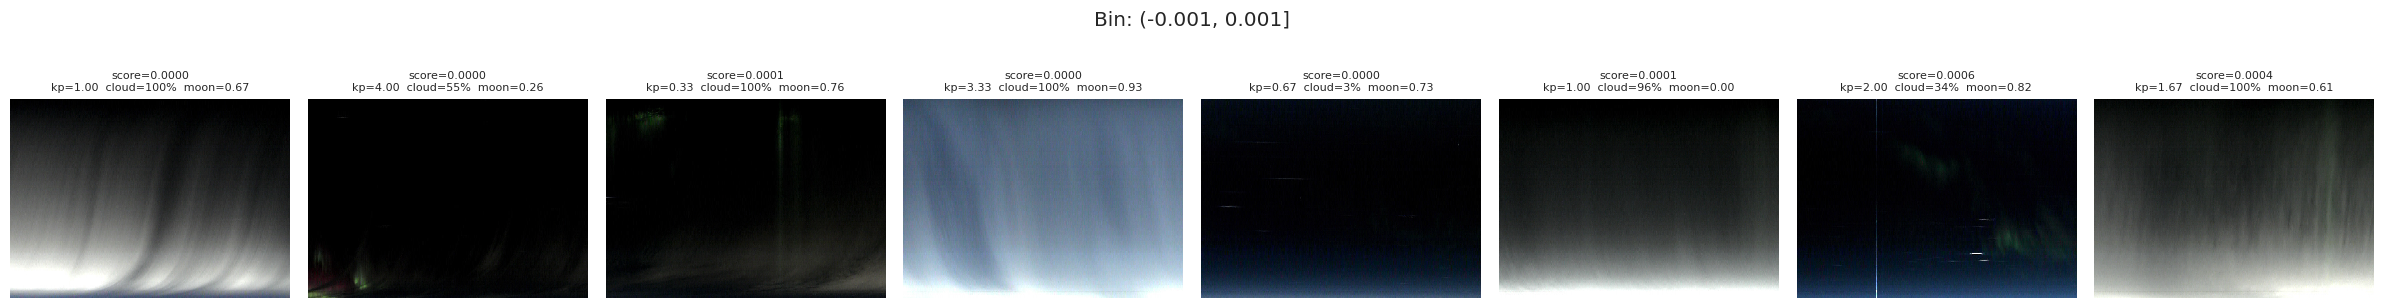

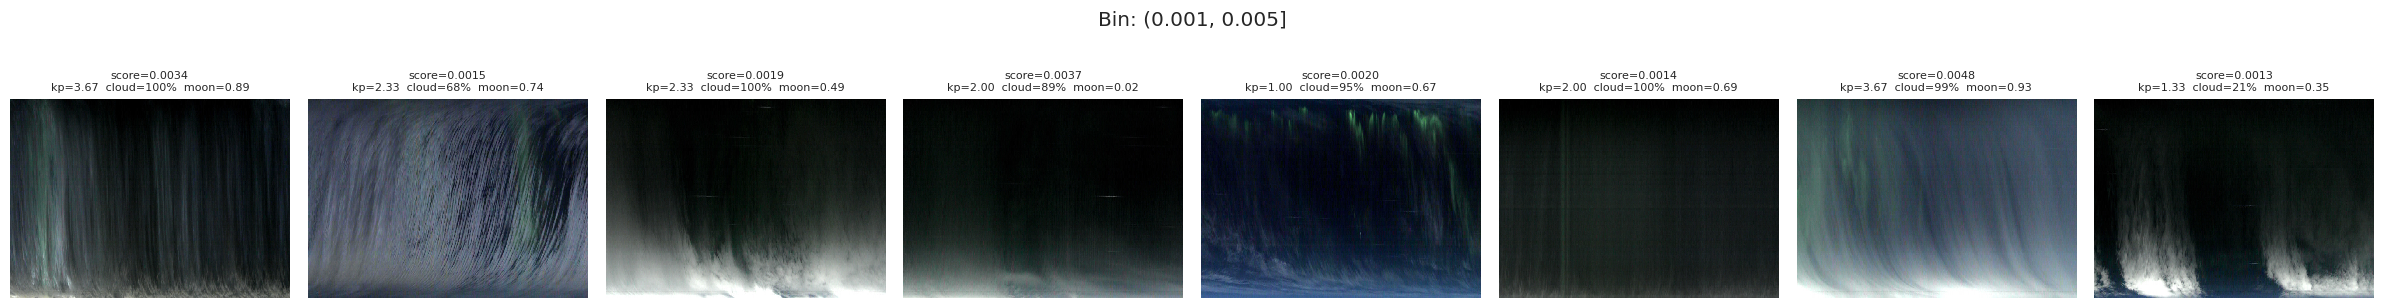

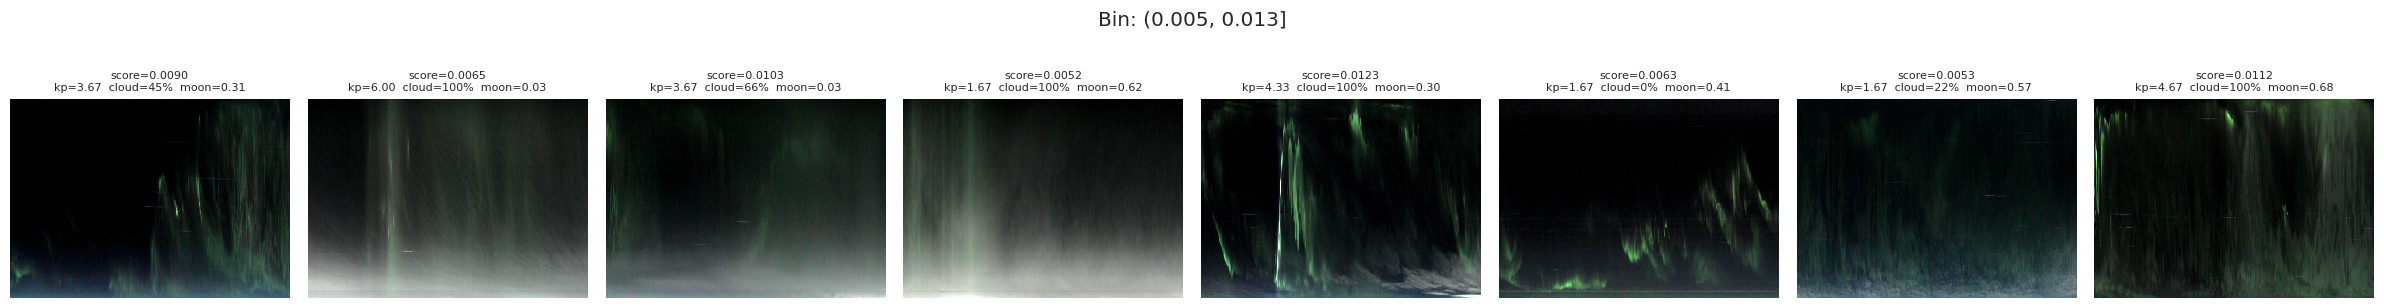

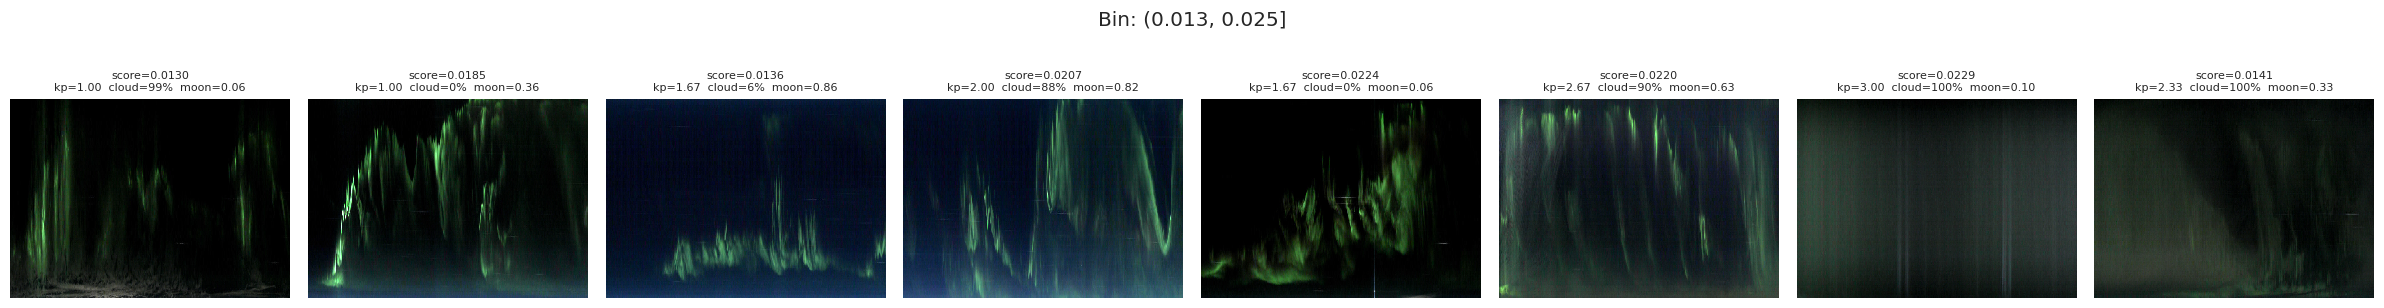

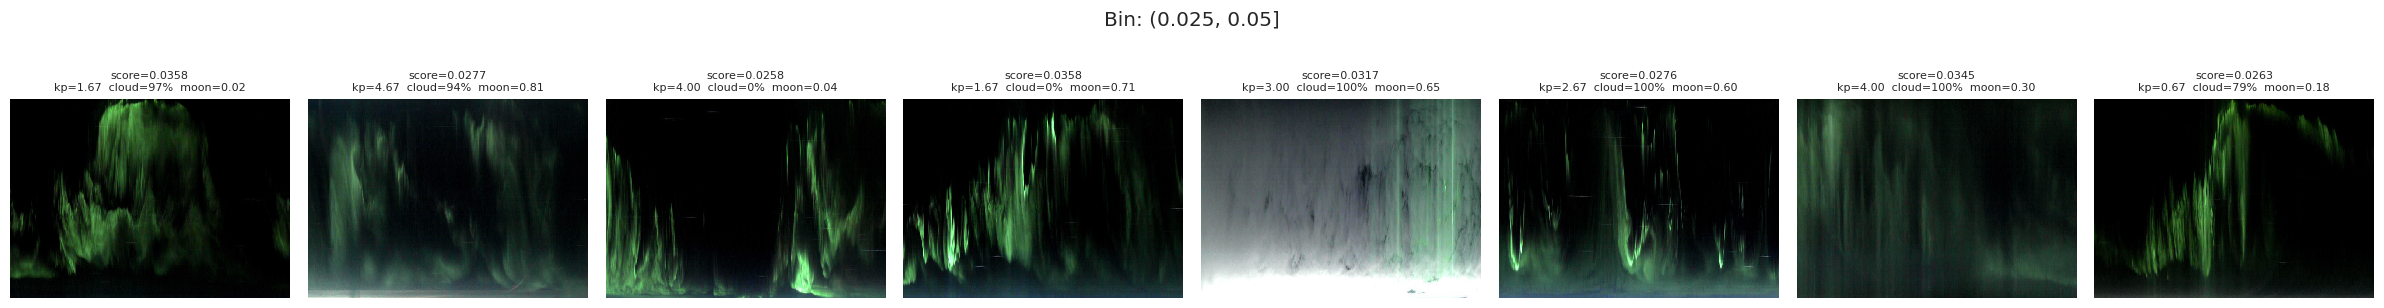

In [299]:

samples[['aurora_score','kp','cloud_cover','moon_illumination','local_path','bin']].head()
# for b, group in samples.groupby('bin'):
#     group = group.reset_index(drop=True)
#     n = len(group)
#     cols = min(5, n)
#     rows = int(np.ceil(n / cols))
#     plt.figure(figsize=(3 * cols, 3 * rows))
#     for i, row in group.iterrows():
#         print(row['local_path'])

for b, group in samples.groupby('bin'):
    group = group.reset_index(drop=True)
    n = len(group)
    cols = min(8, n)
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(3 * cols, 3 * rows))
    for i, row in group.iterrows():
        img = Image.open(row["local_path"]).convert("RGB")
        ax = plt.subplot(rows, cols, i + 1)
        ax.imshow(img, interpolation="nearest", aspect="auto")
        ax.axis("off")

        title = (
            'score={:.4f}\nkp={:.2f}  cloud={:.0f}%  moon={:.2f}'
            .format(row['aurora_score'], row['kp'], row['cloud_cover'], row['moon_illumination'])
        )
        ax.set_title(title, fontsize=8)
    plt.suptitle(f'Bin: {b}', y=1.02)
    plt.tight_layout()
    plt.show()


i think there might be a problem of alignement cloud is 97% in the
  middle one but i dont see any cloud on the keogram

I have a bit of a debate here gpt say :
97% is high, but it can still happen because:

  - Cloud cover is area‑average (grid cell), not the exact camera line‑of‑sight.
  - Aurora can be above clouds, so you still see green.
  - Thin/high clouds may not be obvious in the keogram.
  - There may be time alignment differences (UTC vs local).


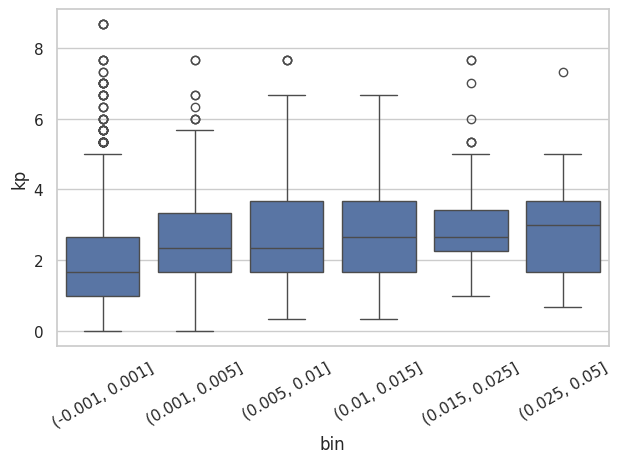

/tmp/ipykernel_37554/3574630499.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  samples = (scores_filt.groupby("bin", group_keys=False)
/tmp/ipykernel_37554/3574630499.py:40: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(5, len(g)), random_state=0)))


In [300]:
import numpy as np

USE_QUANTILES = False
MANUAL_BINS = [0.0, 0.001, 0.005, 0.01, 0.015, 0.025, 0.05]  # used only if USE_QUANTILES = False

scores = scores_df.copy()

if USE_QUANTILES:
  bins = np.quantile(scores["aurora_score"], np.linspace(0, 1, 6))
  bins = np.unique(bins)
else:
  bins = np.array(MANUAL_BINS)

scores["bin"] = pd.cut(scores["aurora_score"], bins=bins, include_lowest=True)

# Attach metadata for ALL rows
meta_cols = ["local_path","kp","cloud_cover","moon_illumination"]
meta = merged[meta_cols].drop_duplicates("local_path")
scores = scores.merge(meta, on="local_path", how="left")

# --- Full‑data distributions (all rows) ---
# Count per bin
scores["bin"].value_counts().sort_index()

# Kp distribution per bin (full data)
sns.boxplot(data=scores, x="bin", y="kp")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# --- If you want to FILTER just for visualization ---
scores_filt = scores[
  (scores["cloud_cover"] < 100) &
  (scores["cloud_cover"] > 70) &
  (scores["moon_illumination"] < 0.2)
].copy()

# Sample 5 per bin only for plotting images
samples = (scores_filt.groupby("bin", group_keys=False)
         .apply(lambda g: g.sample(min(5, len(g)), random_state=0)))



  - Higher aurora_score bins have higher median Kp.
    The median shifts upward from the lowest bin to the mid/high bins, so there
    is a positive relationship.
  - But the overlap is large.
    Low Kp still appears in higher bins, and high Kp appears in lower bins,
    meaning Kp alone doesn’t explain the score.
  - Conclusion: Kp is a contributing factor, not the sole driver. The
    aurora_score reflects other influences (cloud, moon, or image noise) in
    addition to Kp.


/tmp/ipykernel_37554/3182767743.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  event_only.groupby(["year","month","bin"])


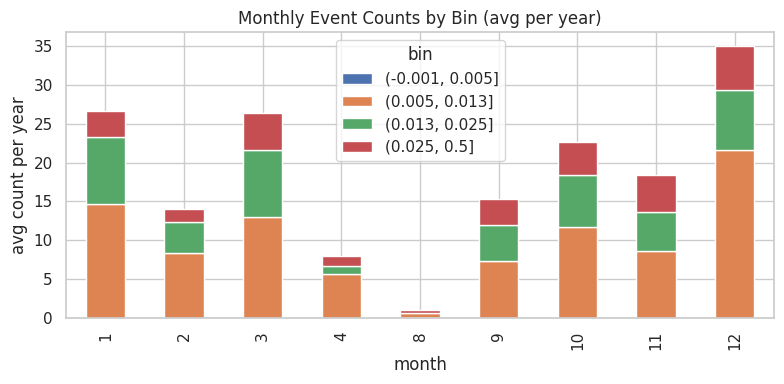

/tmp/ipykernel_37554/3182767743.py:86: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  event_only.groupby(["year", "month", "bin"])
/tmp/ipykernel_37554/3182767743.py:104: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  event_counts_yearly.groupby(["month", "bin"])["event_rate"]


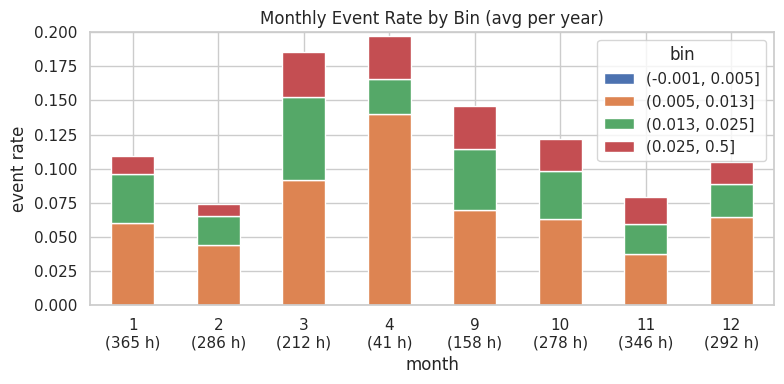

In [302]:
# --- safe reset of meta columns then merge ---
meta_cols = ["local_path","timestamp_utc","cloud_cover","moon_illumination"]
meta = merged[meta_cols].drop_duplicates("local_path")

scores = scores.copy()
for c in ["timestamp_utc","cloud_cover","moon_illumination",

"cloud_cover_x","cloud_cover_y","moon_illumination_x","moon_illumination_y"]:
  if c in scores.columns and c != "local_path":
      scores = scores.drop(columns=[c])

scores = scores.merge(meta, on="local_path", how="left")

# --- Filter ---
CLOUD_MAX = 100
CLOUD_MIN = 0
MOON_MAX = 1

scores_filt = scores[
  (scores["cloud_cover"] <= CLOUD_MAX) &
  (scores["cloud_cover"] >= CLOUD_MIN) &
  (scores["moon_illumination"] < MOON_MAX)
].copy()

# --- Bin ---
MANUAL_BINS = [0.0,  0.005, 0.013, 0.025, 0.5]
scores_filt["bin"] = pd.cut(scores_filt["aurora_score"], bins=MANUAL_BINS,
include_lowest=True)

# Event = bin > first bin
bins = scores_filt["bin"].cat.categories
no_event_bin = bins[0]
event_only = scores_filt[scores_filt["bin"] != no_event_bin].copy()

# --- Weekly event rate (average year) ---
scores_filt["week"] =scores_filt["timestamp_utc"].dt.isocalendar().week.astype(int)
event_only["week"] =event_only["timestamp_utc"].dt.isocalendar().week.astype(int)






# --- Monthly event counts by bin (average per year) ---
event_only["month"] = event_only["timestamp_utc"].dt.month
event_only["year"] = event_only["timestamp_utc"].dt.year

event_counts_yearly = (
  event_only.groupby(["year","month","bin"])
  .size()
  .unstack(fill_value=0)
)

event_counts_avg = event_counts_yearly.groupby("month").mean()

event_counts_avg.plot(kind="bar", stacked=True, figsize=(8,4))
plt.title("Monthly Event Counts by Bin (avg per year)")
plt.xlabel("month")
plt.ylabel("avg count per year")
plt.tight_layout()
plt.show()


import matplotlib.pyplot as plt

# --- add year/month ---
scores_filt = scores_filt.copy()
event_only = event_only.copy()

scores_filt["year"] = scores_filt["timestamp_utc"].dt.year
scores_filt["month"] = scores_filt["timestamp_utc"].dt.month

event_only["year"] = event_only["timestamp_utc"].dt.year
event_only["month"] = event_only["timestamp_utc"].dt.month


# --- total available hours per year-month (after filtering) ---
total_hours = (
    scores_filt.groupby(["year", "month"])
    .size()
    .rename("total_hours")
)

# --- event counts per year-month-bin ---
event_counts_yearly = (
    event_only.groupby(["year", "month", "bin"])
    .size()
    .rename("event_hours")
    .reset_index()
)

# --- join totals and compute rate ---
event_counts_yearly = event_counts_yearly.merge(
    total_hours.reset_index(), on=["year", "month"], how="left"
)

event_counts_yearly["event_rate"] = (
    event_counts_yearly["event_hours"] / event_counts_yearly["total_hours"]
)


# --- average rate per month/bin across years (stacked bars) ---
event_rate_avg = (
    event_counts_yearly.groupby(["month", "bin"])["event_rate"]
    .mean()
    .unstack(fill_value=0)
)

# --- filter out months with too few hours (avg across years) ---
min_hours = 10
month_hours = total_hours.reset_index().groupby("month")["total_hours"].mean()
valid_months = month_hours[month_hours >= min_hours].index

event_rate_avg = event_rate_avg.loc[valid_months]

# --- x tick labels: month + avg hours ---
labels = [f"{m}\n({int(month_hours.loc[m])} h)" for m in event_rate_avg.index]

# --- plot ---
ax = event_rate_avg.plot(kind="bar", stacked=True, figsize=(8, 4))
ax.set_xticklabels(labels, rotation=0)

plt.title("Monthly Event Rate by Bin (avg per year)")
plt.xlabel("month")
plt.ylabel("event rate")
plt.ylim((0,0.2))
plt.tight_layout()
plt.show()


  - This is absolute event hours per month, not normalized.
  - December has the most event hours, followed by Jan/Mar/Oct/Nov.
  - This reflects more available dark hours in winter, so counts are larger even
    if the rate is not maximal.
  - Stronger bins appear mostly in Oct–Dec, indicating that intense aurora
    events cluster in late autumn/early winter.


  Figure — Monthly Event Rate by Bin (avg per year)

  - This is normalized by available hours, so it shows the probability of event
    hours each month.
  - March–April show the highest event rates (~0.15–0.20), suggesting a spring
    peak.
  - Autumn (Sep–Nov) shows a secondary peak (~0.08–0.12).
  - Most of the rate comes from the lowest event bin; stronger‑bin events are
    rare.


  - Rate peak (chance per hour) is in spring,
  - Total event hours peak in winter because there are more dark hours.

